# 関係モデルの基礎 Notebook：2人の線形ODE

対応章: [`../chapters/07_love_dynamics_basic.md`](../chapters/07_love_dynamics_basic.md)

2変数線形系の固有値、時系列、相図を照合する。外力、飽和、作品データへの適合は扱わない。

## 1. ライブラリと係数行列

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

M = np.array([[-0.2, 1.0], [-1.0, -0.2]])
x0 = np.array([1.0, 0.2])
print('M =\n', M)

M =
 [[-0.2  1. ]
 [-1.  -0.2]]


## 2. 数値積分前に固有値から予想する

In [2]:
trace = np.trace(M)
determinant = np.linalg.det(M)
eigenvalues = np.linalg.eigvals(M)
discriminant = trace**2 - 4*determinant
print(f'trace={trace:.3f}, determinant={determinant:.3f}, discriminant={discriminant:.3f}')
print('eigenvalues:', eigenvalues)
print('prediction: all real parts are negative -> trajectories approach the origin')

trace=-0.400, determinant=1.040, discriminant=-4.000
eigenvalues: [-0.2+1.j -0.2-1.j]
prediction: all real parts are negative -> trajectories approach the origin


## 3. 時系列を計算する

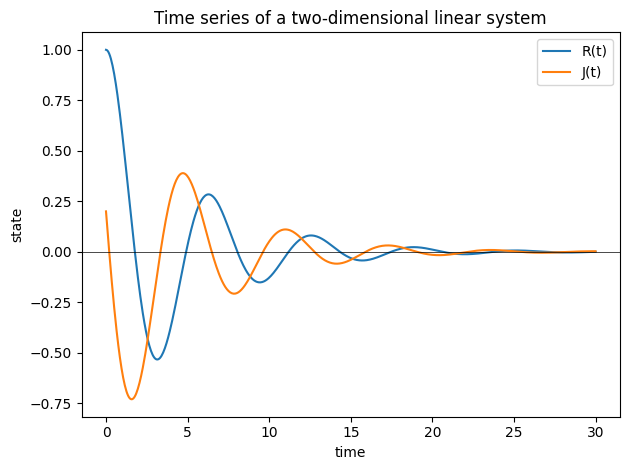

In [3]:
def rhs(t, state, matrix):
    return matrix @ state

t_eval = np.linspace(0, 30, 600)
solution = solve_ivp(rhs, (t_eval[0], t_eval[-1]), x0, t_eval=t_eval, args=(M,))
plt.plot(solution.t, solution.y[0], label='R(t)')
plt.plot(solution.t, solution.y[1], label='J(t)')
plt.axhline(0, color='black', lw=0.5)
plt.xlabel('time'); plt.ylabel('state')
plt.title('Time series of a two-dimensional linear system')
plt.legend(); plt.tight_layout(); plt.show()

## 4. ベクトル場と軌道を照合する

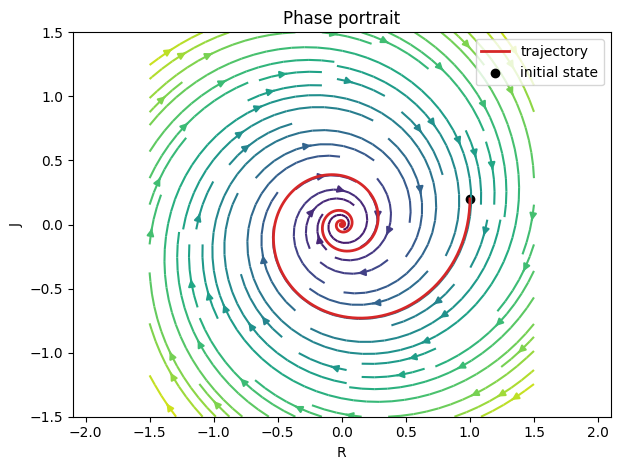

In [4]:
grid = np.linspace(-1.5, 1.5, 17)
R, J = np.meshgrid(grid, grid)
dR = M[0, 0]*R + M[0, 1]*J
dJ = M[1, 0]*R + M[1, 1]*J
speed = np.hypot(dR, dJ)
plt.streamplot(R, J, dR, dJ, color=speed, cmap='viridis', density=1.0)
plt.plot(solution.y[0], solution.y[1], color='tab:red', lw=2, label='trajectory')
plt.scatter([x0[0]], [x0[1]], color='black', label='initial state')
plt.xlabel('R'); plt.ylabel('J'); plt.title('Phase portrait')
plt.axis('equal'); plt.legend(); plt.tight_layout(); plt.show()

## 5. 3つの行列を固有値で分類する

In [5]:
cases = {
    'stable node': np.array([[-1.0, 0.2], [0.2, -0.6]]),
    'saddle': np.array([[0.6, 0.0], [0.0, -0.8]]),
    'stable focus': np.array([[-0.2, 1.0], [-1.0, -0.2]]),
}
for name, matrix in cases.items():
    print(f'{name:12s}: eigenvalues={np.linalg.eigvals(matrix)}')

stable node : eigenvalues=[-1.08284271 -0.51715729]
saddle      : eigenvalues=[ 0.6 -0.8]
stable focus: eigenvalues=[-0.2+1.j -0.2-1.j]


## 6. 課題

1. `M` の固有値を手計算し、Notebookの値と照合する。
2. 安定節点、鞍点、安定焦点の初期値を変え、分類が保たれることを確認する。
3. 線形モデルが発散する係数を選び、数値計算の発散とモデルが予測する発散を区別する。
4. 外力、飽和、第三者効果はまだ実装せず、どんな観測残差があれば各拡張を検討するか文章で書く。